In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
    #for filename in filenames:
        #print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:black;
           font-size:110%;
           font-family:Verdana;
           letter-spacing:0.5px">

<p style="padding: 10px;
              color:white;
              text-align:center;">
                            Data Info
              
</p>
</div>

What's the meaning of BMD?

Bone mineral density: BMD, a measure of bone density, reflecting the strength of bones as represented by calcium content. The BMD test detects osteopenia (mild bone loss, usually without symptoms) and osteoporosis (more severe bone loss, which may cause symptoms).


In this notebook we will try to find the answers to following questions:

1. Are women more at risk than men for osteoporosis??

2. Does age has any affect on bmd score?

3. Does Weight & height has any affect on bmd score?

4. At which age fractures are more common in male & female?

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import missingno as msno

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
#from xgboost import XGBRFRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn import metrics

In [2]:
df = pd.read_csv('bmd.csv')
df.head()

NameError: name 'pd' is not defined

In [ ]:
print(f'Dataframe has {df.shape[0]} rows & {df.shape[1]} columns')

Dataframe has 169 rows & 9 columns


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            169 non-null    int64  
 1   age           169 non-null    float64
 2   sex           169 non-null    object 
 3   fracture      169 non-null    object 
 4   weight_kg     169 non-null    float64
 5   height_cm     169 non-null    float64
 6   medication    169 non-null    object 
 7   waiting_time  169 non-null    int64  
 8   bmd           169 non-null    float64
dtypes: float64(4), int64(2), object(3)
memory usage: 12.0+ KB


In [ ]:
df.isna().sum()

id              0
age             0
sex             0
fracture        0
weight_kg       0
height_cm       0
medication      0
waiting_time    0
bmd             0
dtype: int64

<Axes: >

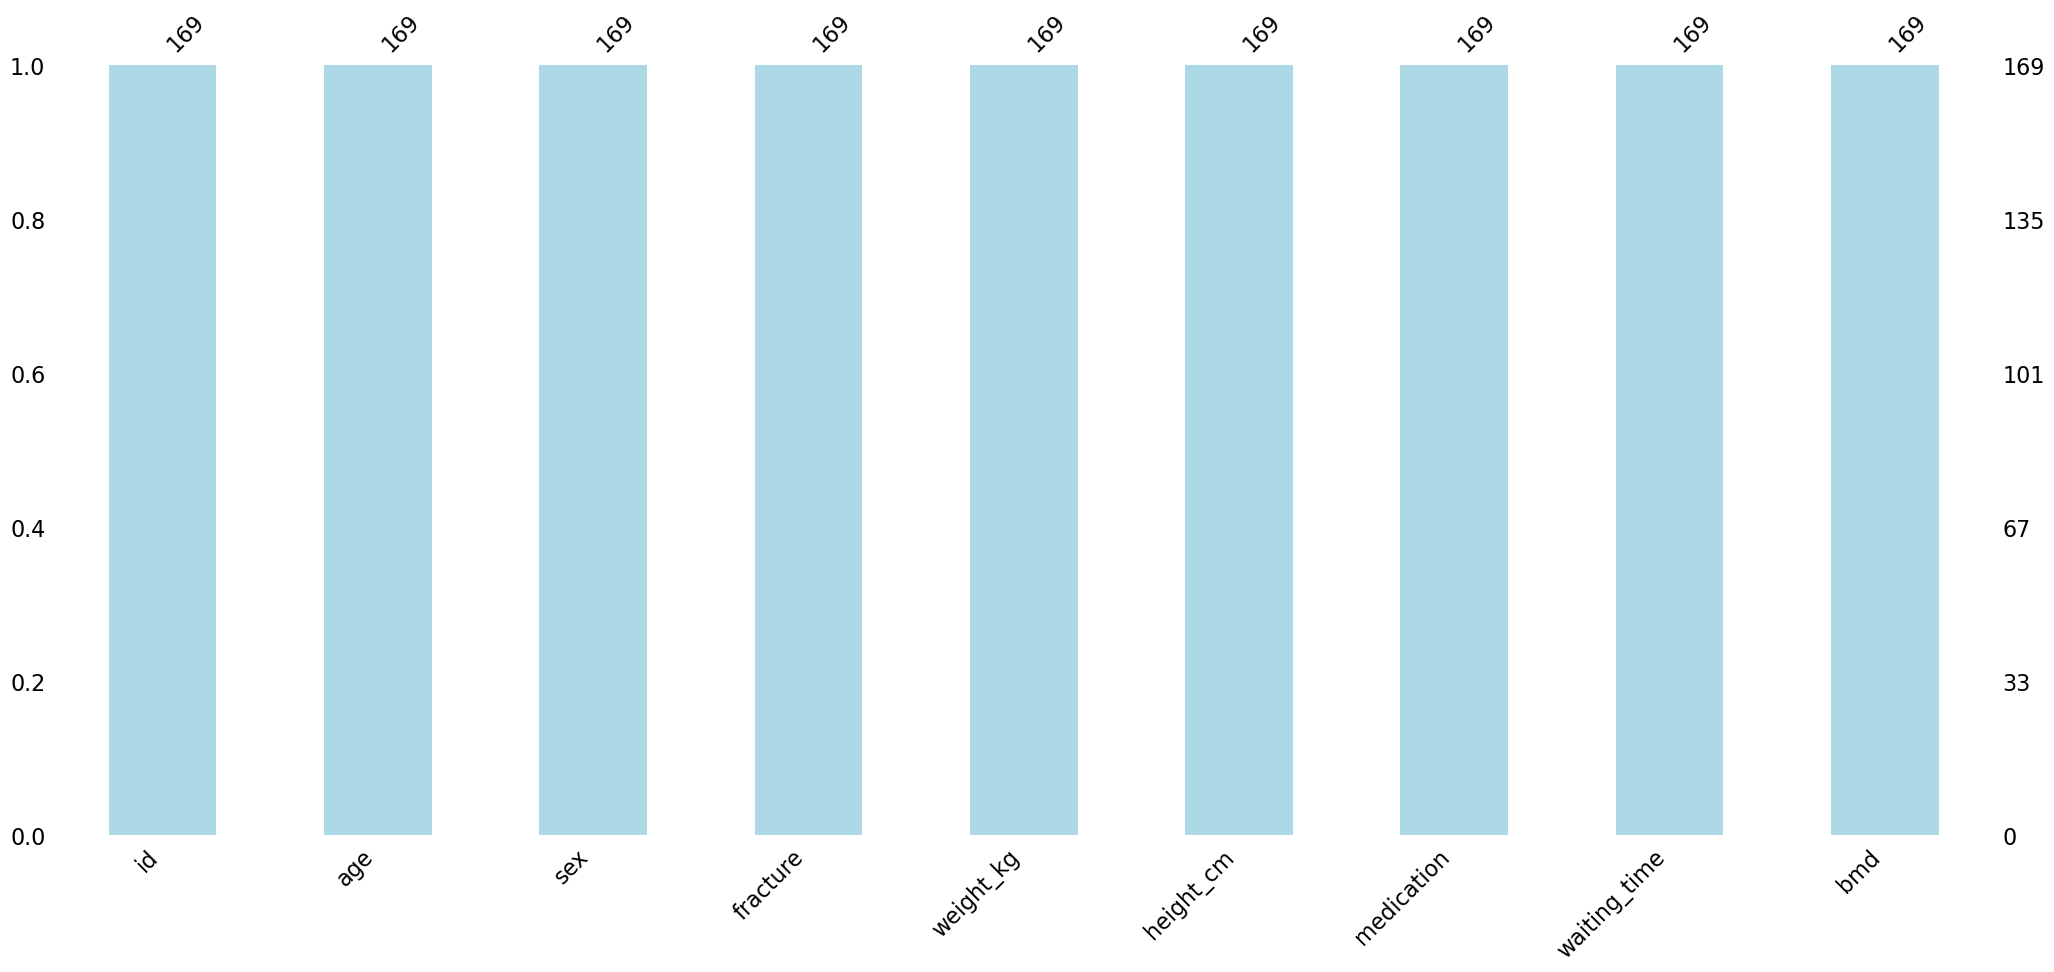

In [ ]:
msno.bar(df,color='lightblue')

In [ ]:
df.describe()

,id,age,weight_kg,height_cm,waiting_time,bmd
count,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000
mean,9102.556213,63.631531,64.665680,160.254438,19.739645,0.783104
std,8744.623598,12.356936,11.537171,7.928272,15.800570,0.166529
min,35.000000,35.814058,36.000000,142.000000,5.000000,0.407600
25%,2018.000000,54.424211,56.000000,154.000000,9.000000,0.670800
50%,6702.000000,63.487837,64.500000,160.500000,14.000000,0.786100
75%,17100.000000,72.080558,73.000000,166.000000,24.000000,0.888800
max,24208.000000,88.753795,96.000000,177.000000,96.000000,1.362400


In [ ]:
df['age'] = df['age'].astype('int')

<Axes: >

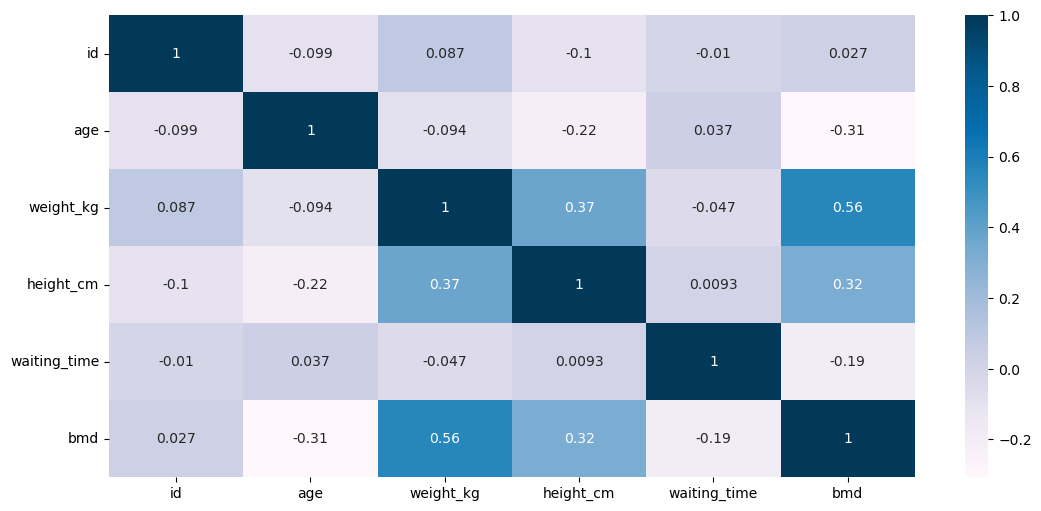

In [ ]:
# Drop non-numeric columns
df_numeric = df.select_dtypes(include=[np.number])

plt.figure(figsize=(13,6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='PuBu')

Body weight is directly associated with bone mineral density (BMD) thats's why bmd has stronger correaltion with weight in comparision to other features.


<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:lightblue;
           font-size:110%;
           font-family:Verdana;
           letter-spacing:0.5px">

<p style="padding: 10px;
              color:black;
              text-align:center;">
                            EDA
              
</p>
</div>

In [ ]:
fig = make_subplots(rows=1,cols=2,subplot_titles=['BMD Visualization With Histogram','BMD Visualization With Boxplot'])

fig.add_traces(go.Histogram(x=df['bmd'],marker=dict(color='salmon')),1,1)

fig.add_traces(go.Box(y=df['bmd']),1,2)

fig.update_layout(margin={'b':0,'l':0,'r':0,'t':100},
                  paper_bgcolor='rgb(428,428,455)',
                  plot_bgcolor='rgb(428,428,455)',
                  title_text='BMD visualization',
                  title={'font':{
                             'family':'monospace',
                             'size':22,
                             'color': 'grey'
                         },
                        'x':0.45,'y':0.9},
                 showlegend=False)

fig.show()

In [ ]:
fig = make_subplots(rows=1,cols=2,subplot_titles=['Age Visualization With Histogram','Age Visualization With Boxplot'])

fig.add_traces(go.Histogram(x=df['age'],marker=dict(color='lightblue')),1,1)

fig.add_traces(go.Box(y=df['age'],marker=dict(color='lightblue')),1,2)

fig.update_layout(margin={'b':0,'l':0,'r':0,'t':100},
                  paper_bgcolor='rgb(428,428,455)',
                  plot_bgcolor='rgb(428,428,455)',
                  title_text='Age Visualization',
                  title={'font':{
                             'family':'monospace',
                             'size':22,
                             'color': 'grey'
                         },
                        'x':0.45,'y':0.9},
                 showlegend=False)

fig.show()

In [ ]:
fig = make_subplots(rows=1,cols=2,subplot_titles=['Weight Visualization With Histogram','Weight Visualization With Boxplot'])

fig.add_traces(go.Histogram(x=df['weight_kg'],
                            xbins=dict(start=30,end=100),
                            marker=dict(color='lightgreen')),1,1)

fig.add_traces(go.Box(y=df['weight_kg'],marker=dict(color='lightgreen')),1,2)

fig.update_layout(margin={'b':0,'l':0,'r':0,'t':100},
                  paper_bgcolor='rgb(428,428,455)',
                  plot_bgcolor='rgb(428,428,455)',
                  title_text='Weight Visualization',
                  title={'font':{
                             'family':'monospace',
                             'size':22,
                             'color': 'grey'
                         },
                        'x':0.45,'y':0.9},
                 showlegend=False)

fig.show()

In [ ]:
fig = make_subplots(rows=1,cols=2,subplot_titles=['Height Visualization With Histogram','Height Visualization With Boxplot'])

fig.add_traces(go.Histogram(x=df['height_cm'],
                            xbins=dict(start=120,end=190),
                            marker=dict(color='plum')),1,1)

fig.add_traces(go.Box(y=df['height_cm'],marker=dict(color='plum')),1,2)

fig.update_layout(margin={'b':0,'l':0,'r':0,'t':100},
                  paper_bgcolor='rgb(428,428,455)',
                  plot_bgcolor='rgb(428,428,455)',
                  title_text='Height Visualization',
                  title={'font':{
                             'family':'monospace',
                             'size':22,
                             'color': 'grey'
                         },
                        'x':0.45,'y':0.9},
                 showlegend=False)

fig.show()

In [ ]:
fig = px.bar(x = df['fracture'].value_counts().index,
             y = df['fracture'].value_counts(),
             text = df['fracture'].value_counts())

fig.update_traces(textposition='outside',marker=dict(color='lightyellow',line=dict(color='gold')))
fig.update_layout(margin={'b':0,'l':0,'r':0,},
                 paper_bgcolor='rgb(248, 248, 255)',
                 plot_bgcolor='rgb(248, 248, 255)',
                 title={'font':{
                             'family':'monospace',
                             'size':22,
                             'color': 'grey'
                         },
                        'x':0.45,'y':0.9},
                 width=700)
fig.show()

In [ ]:
fig = px.pie(names=df['sex'].value_counts().index,
             values = df['sex'].value_counts(),
            hole=.5)

fig.add_annotation(showarrow=False,x=0.50,y=0.5,text='Gender Distribution',font=dict(size=13,color='grey'))
fig.add_annotation(showarrow=False,x=0.28,y=0.5,text='Female',font=dict(size=13,color='grey'))
fig.add_annotation(showarrow=False,x=0.73,y=0.5,text='Male',font=dict(size=13,color='grey'))

fig.update_traces(marker=dict(colors=['lightblue','pink']))

fig.update_layout(margin={'b':0,'l':0,'r':0,},
                 paper_bgcolor='rgb(248, 248, 255)',
                 plot_bgcolor='rgb(248, 248, 255)',
                 title_text='Gender Distribution',
                 title={'font':{
                             'family':'monospace',
                             'size':22,
                             'color': 'grey'
                         },
                        'x':0.48,'y':0.9},
                 height=500,
                 showlegend=False)
fig.show()

Women start losing bone at an earlier age and at a faster rate than men.

Women ≥ 50 years of age have a four times higher rate of osteoporosis and a two times higher rate of osteopenia, 

and they tend to have fractures 5 - 10 years earlier compared with men.

Lets see what this data has to say about that.

In [ ]:
fig = px.scatter(x=df['bmd'],color=df['sex'],symbol=df['sex'],color_discrete_sequence=['hotpink','steelblue'])

fig.update_layout(margin={'b':0,'l':0,'r':0,},
                 paper_bgcolor='rgb(248, 248, 255)',
                 plot_bgcolor='rgb(248, 248, 255)',
                 title_text='Gender BMD Distribution',
                 title={'font':{
                             'family':'monospace',
                             'size':22,
                             'color': 'grey'
                         },
                        'x':0.48,'y':0.9},
                 height=500,
                 showlegend=False)

fig.show()

We can see clearly that BMD score in Males is higher than that of females:

BMD score range of Male is (0.4 - 1.4).

Bmd scaore range of female is (0.4 - 1).

This answers our question are women more at risk than men for osteoporosis?

In [ ]:
female = df[df['sex']=='F']
male = df[df['sex']=='M']

fig = make_subplots(rows=1, cols=2)

trace0 = go.Scatter(x=female['age'],y=female['bmd'],mode='markers',marker=dict(color='hotpink'))

trace1 = go.Scatter(x=male['age'],y=male['bmd'],mode='markers',marker=dict(color='steelblue'))


fig.add_traces(trace0,1,1)
fig.add_traces(trace1,1,2)

fig.add_annotation(showarrow=False,x=60,y=1,text='Female BMD',font=dict(size=15,color='hotpink'))
fig.add_annotation(showarrow=False,x=0.8,y=1,xref="paper",text='Male BMD',font=dict(size=15,color='steelblue'))

fig.update_layout(margin={'b':0,'l':0,'r':0,},
                 paper_bgcolor='rgb(248, 248, 255)',
                 plot_bgcolor='rgb(248, 248, 255)',
                 title_text='Gender BMD Distribution According To Age',
                 title={'font':{
                             'family':'monospace',
                             'size':22,
                             'color': 'grey'
                         },
                        'x':0.48,'y':0.9},
                 showlegend=False)
fig.show()


Age does have affects on bmd score as we can see in the graph as the age increases bmd score decreases.

In [ ]:
fig = px.scatter(x=df['weight_kg'], y=df['bmd'],trendline='ols',trendline_color_override='black')

fig.update_traces(marker=dict(color='orange'))

fig.update_layout(margin={'b':0,'l':0,'r':0,},
                 paper_bgcolor='rgb(248, 248, 255)',
                 plot_bgcolor='rgb(248, 248, 255)',
                 title_text='Does Weight Affect BMD Score?',
                 title={'font':{
                             'family':'monospace',
                             'size':22,
                             'color': 'grey'
                         },
                        'x':0.48,'y':0.9},
                 showlegend=False)
fig.show()

BMD has high correlation with weight, as the weight increase bmd also increases.

In [ ]:
fig = px.scatter(x=df['height_cm'], y=df['bmd'],trendline='ols',trendline_color_override='purple')

fig.update_traces(marker=dict(color='plum'))

fig.update_layout(margin={'b':0,'l':0,'r':0,},
                 paper_bgcolor='rgb(248, 248, 255)',
                 plot_bgcolor='rgb(248, 248, 255)',
                 title_text='Does Height Affect BMD Score?',
                 title={'font':{
                             'family':'monospace',
                             'size':22,
                             'color': 'grey'
                         },
                        'x':0.48,'y':0.9},
                 showlegend=False)
fig.show()

There is little to no relation between height and bmd score

In [ ]:
fractures = df.groupby('sex')['fracture'].value_counts().reset_index(name='count')

fig = px.bar(x=fractures['sex'],
             y=fractures['count'],
             color=fractures['fracture'],
             barmode='group',
             text=fractures['count'])
fig.update_layout(margin={'b':0,'l':0,'r':0,},
                 paper_bgcolor='rgb(248, 248, 255)',
                 plot_bgcolor='rgb(248, 248, 255)',
                 title_text='Gender & Fracture Counts',
                 title={'font':{
                             'family':'monospace',
                             'size':22,
                             'color': 'grey'
                         },
                        'x':0.48,'y':0.9})
fig.show()

In this data male & female fracture ratio is same so it's hard to say who is more likely to suffer from fracture the most.

In [ ]:
fig = px.scatter(df, x="age", y="bmd", color="fracture", facet_col="sex")

fig.update_layout(margin={'b':0,'l':0,'r':0,'t':150},
                 paper_bgcolor='rgb(248, 248, 255)',
                 plot_bgcolor='rgb(248, 248, 255)',
                 title_text='At which age fratures are most common in male & female?',
                 title={'font':{
                             'family':'monospace',
                             'size':22,
                             'color': 'grey'
                         },
                        'x':0.48,'y':0.9})
fig.show()

We can see in the graph that fractures are more common from age 68 to 85 in female,

and in male fractures are common from age 65 to 89.

In [ ]:
fig = px.bar(x=df['medication'].value_counts().index,
             y = df['medication'].value_counts(),
             text=(df['medication'].value_counts()/len(df['medication'])*100))
fig.update_traces(textposition='outside',texttemplate='%{text:.4s}%',marker=dict(color='silver',line=dict(color='grey')))

fig.update_layout(margin={'b':0,'l':0,'r':0,'t':150},
                 paper_bgcolor='rgb(248, 248, 255)',
                 plot_bgcolor='rgb(248, 248, 255)',
                 title_text='Medication Count',
                 title={'font':{
                             'family':'monospace',
                             'size':22,
                             'color': 'grey'
                         },
                        'x':0.48,'y':0.9})
fig.show()


80% of people doesn't take any medication.

14% takes Glucocorticoids medicine, Glucocorticoids are medicines that fight inflammation and work with your immune system to treat wide range of health problems

5% takes Anticonvulsant medicine, used to prevent or stop seizures or convulsions


In [ ]:
fig = px.scatter(x=df['bmd'],color=df['medication'])

fig.update_layout(margin={'b':0,'l':0,'r':0,'t':150},
                 paper_bgcolor='rgb(248, 248, 255)',
                 plot_bgcolor='rgb(248, 248, 255)',
                 title_text='Does Medication Helps With BMD Score?',
                 title={'font':{
                             'family':'monospace',
                             'size':22,
                             'color': 'grey'
                         },
                        'x':0.48,'y':0.9})
fig.show()

In [ ]:
meds = df.groupby('sex')['medication'].value_counts().reset_index(name='count')

fig = px.bar(x=meds['sex'],
             y=meds['count'],
             color=meds['medication'],
             barmode='group',
             text=meds['count'])

fig.update_traces(textposition='outside')

fig.update_layout(margin={'b':0,'l':0,'r':0,'t':150},
                 paper_bgcolor='rgb(248, 248, 255)',
                 plot_bgcolor='rgb(248, 248, 255)',
                 title_text='Who takes more Medication Male or Female?',
                 title={'font':{
                             'family':'monospace',
                             'size':22,
                             'color': 'grey'
                         },
                        'x':0.48,'y':0.9})

fig.show()

In [ ]:
fig = px.scatter(df, x="age",color="medication", facet_col="sex")

fig.update_layout(margin={'b':0,'l':0,'r':0,'t':150},
                 paper_bgcolor='rgb(248, 248, 255)',
                 plot_bgcolor='rgb(248, 248, 255)',
                 title_text='Gender, Age & Medication',
                 title={'font':{
                             'family':'monospace',
                             'size':22,
                             'color': 'grey'
                         },
                        'x':0.48,'y':0.9})
fig.show()

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:lightblue;
           font-size:110%;
           font-family:Verdana;
           letter-spacing:0.5px">

<p style="padding: 10px;
              color:black;
              text-align:center;">
                            Data Scaling & Encoding
              
</p>
</div>

In [ ]:
df = df.replace({'M':1,'F':0,'No medication':0,'Glucocorticoids':1,'Anticonvulsant':2,'no fracture':0,'fracture':1})

In [ ]:
cols_to_scale = ['age','weight_kg','height_cm']

#create and fit scaler
scaler = StandardScaler()
scaler.fit(df[cols_to_scale])

#scale selected data
df[cols_to_scale] = scaler.transform(df[cols_to_scale])

In [ ]:
df = pd.get_dummies(df, columns=['sex', 'fracture','medication'], drop_first=True)

In [ ]:
x = df.iloc[:,:-1]
y = df['bmd']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.2,random_state=42)

In [ ]:
def cross_val(model):
    pred = cross_val_score(model,x,y,cv=10)
    return pred.mean()

def print_evaluate(true,predicted):
    mae = metrics.mean_absolute_error(true,predicted)
    mse = metrics.mean_squared_error(true,predicted)
    rmse = np.sqrt(metrics.mean_squared_error(true,predicted))
    r2_square = metrics.r2_score(true,predicted)
    print('MAE:', mae)
    print('MSE:', mse)
    print('RMSE:', rmse)
    print('R2 Square', r2_square)
    print('__________________________________')
    
def evaluate(true, predicted):
    mae = metrics.mean_absolute_error(true, predicted)
    mse = metrics.mean_squared_error(true, predicted)
    rmse = np.sqrt(metrics.mean_squared_error(true, predicted))
    r2_square = metrics.r2_score(true, predicted)
    return mae, mse, rmse, r2_square
    

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:lightblue;
           font-size:110%;
           font-family:Verdana;
           letter-spacing:0.5px">

<p style="padding: 10px;
              color:black;
              text-align:center;">
                            Linear Regression
              
</p>
</div>

In [ ]:
lin = LinearRegression()
lin.fit(x_train,y_train)

pred = lin.predict(x_test)

print_evaluate(y_test,pred)

MAE: 3.4635693006467754e-14
MSE: 1.7669654087854636e-27
RMSE: 4.203528766150487e-14
R2 Square 1.0
__________________________________


In [ ]:
result_df = pd.DataFrame(data=[['Linear Regression', *evaluate(y_test,pred),cross_val(LinearRegression())]],
                        columns=['Model','MAE','MSE','RMSE','R2','Cross_val'])
result_df

,Model,MAE,MSE,RMSE,R2,Cross_val
0,Linear Regression,3.463569e-14,1.766965e-27,4.203529e-14,1.0,1.0


<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:lightblue;
           font-size:110%;
           font-family:Verdana;
           letter-spacing:0.5px">

<p style="padding: 10px;
              color:black;
              text-align:center;">
                            Ridge Regression
              
</p>
</div>

In [ ]:
ridge = Ridge()
ridge.fit(x_train,y_train)
pred = ridge.predict(x_test)

print_evaluate(y_test,pred)

MAE: 0.030981334612131456
MSE: 0.0014769278391158242
RMSE: 0.038430818871263
R2 Square 0.936653560926558
__________________________________


In [ ]:
result_df2 = pd.DataFrame(data=[['Ridge Regression', *evaluate(y_test,pred), cross_val(Ridge())]],
                          columns=['Model','MAE','MSE','RMSE','R2','Cross_val'])

result_df = pd.concat([result_df,result_df2], ignore_index=True)
result_df

,Model,MAE,MSE,RMSE,R2,Cross_val
0,Linear Regression,3.463569e-14,1.766965e-27,4.203529e-14,1.000000,1.000000
1,Ridge Regression,3.098133e-02,1.476928e-03,3.843082e-02,0.936654,0.673273


<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:lightblue;
           font-size:110%;
           font-family:Verdana;
           letter-spacing:0.5px">

<p style="padding: 10px;
              color:black;
              text-align:center;">
                            Lasso Regression
              
</p>
</div>

In [ ]:
lasso = Lasso()
lasso.fit(x_train,y_train)
pred = lasso.predict(x_test)

print_evaluate(y_test,pred)

MAE: 0.12049888640053469
MSE: 0.024705254291418528
RMSE: 0.15717905169397903
R2 Square -0.05962515183011785
__________________________________


In [ ]:
result_df3 = pd.DataFrame(data=[['Lasso Regression', *evaluate(y_test,pred), cross_val(Lasso())]],
                          columns=['Model','MAE','MSE','RMSE','R2','Cross_val'])

result_df = pd.concat([result_df,result_df3], ignore_index=True)
result_df

,Model,MAE,MSE,RMSE,R2,Cross_val
0,Linear Regression,3.463569e-14,1.766965e-27,4.203529e-14,1.000000,1.000000
1,Ridge Regression,3.098133e-02,1.476928e-03,3.843082e-02,0.936654,0.673273
2,Lasso Regression,1.204989e-01,2.470525e-02,1.571791e-01,-0.059625,-8.310340


<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:lightblue;
           font-size:110%;
           font-family:Verdana;
           letter-spacing:0.5px">

<p style="padding: 10px;
              color:black;
              text-align:center;">
                            DecisionTree Regression
              
</p>
</div>

In [ ]:
dt = DecisionTreeRegressor()
dt.fit(x_train,y_train)
pred = dt.predict(x_test)

print_evaluate(y_test,pred)

MAE: 0.007876470588235304
MSE: 0.00016719521635427618
RMSE: 0.012930398924792544
R2 Square 0.9928288835069304
__________________________________


In [ ]:
result_df4 = pd.DataFrame(data=[['Decissiontree Regression', *evaluate(y_test,pred), cross_val(DecisionTreeRegressor())]],
                          columns=['Model','MAE','MSE','RMSE','R2','Cross_val'])

result_df = pd.concat([result_df,result_df4], ignore_index=True)
result_df

,Model,MAE,MSE,RMSE,R2,Cross_val
0,Linear Regression,3.463569e-14,1.766965e-27,4.203529e-14,1.000000,1.000000
1,Ridge Regression,3.098133e-02,1.476928e-03,3.843082e-02,0.936654,0.673273
2,Lasso Regression,1.204989e-01,2.470525e-02,1.571791e-01,-0.059625,-8.310340
3,Decissiontree Regression,7.876471e-03,1.671952e-04,1.293040e-02,0.992829,0.823417


<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:lightblue;
           font-size:110%;
           font-family:Verdana;
           letter-spacing:0.5px">

<p style="padding: 10px;
              color:black;
              text-align:center;">
                            RandomForest Regression
              
</p>
</div>

In [ ]:
rf = RandomForestRegressor()
rf.fit(x_train,y_train)
pred = rf.predict(x_test)

print_evaluate(y_test,pred)

MAE: 0.006263704902941114
MSE: 8.126319206403225e-05
RMSE: 0.009014609923010106
R2 Square 0.9965145664475528
__________________________________


In [ ]:
result_df5 = pd.DataFrame(data=[['Randomforest Regression', *evaluate(y_test,pred), cross_val(RandomForestRegressor())]],
                          columns=['Model','MAE','MSE','RMSE','R2','Cross_val'])

result_df = pd.concat([result_df,result_df5], ignore_index=True)
result_df

,Model,MAE,MSE,RMSE,R2,Cross_val
0,Linear Regression,3.463569e-14,1.766965e-27,4.203529e-14,1.000000,1.000000
1,Ridge Regression,3.098133e-02,1.476928e-03,3.843082e-02,0.936654,0.673273
2,Lasso Regression,1.204989e-01,2.470525e-02,1.571791e-01,-0.059625,-8.310340
3,Decissiontree Regression,7.876471e-03,1.671952e-04,1.293040e-02,0.992829,0.823417
4,Randomforest Regression,6.263705e-03,8.126319e-05,9.014610e-03,0.996515,0.952506


<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:lightblue;
           font-size:110%;
           font-family:Verdana;
           letter-spacing:0.5px">

<p style="padding: 10px;
              color:black;
              text-align:center;">
                            XGBOOST Regression
              
</p>
</div>

In [ ]:
#xgb = XGBRFRegressor()
#xgb.fit(x_train,y_train)
#pred = xgb.predict(x_test)

#print_evaluate(y_test,pred)

In [ ]:
#result_df6 = pd.DataFrame(data=[['XGBRegression', *evaluate(y_test,pred), cross_val(XGBRFRegressor())]],
#columns=['Model','MAE','MSE','RMSE','R2','Cross_val'])

#result_df = pd.concat([result_df,result_df6], ignore_index=True)
#result_df

In [ ]:
fig = px.bar(x=result_df['R2'],
             y=result_df['Model'],
             orientation='h',
             text=result_df['R2'])

fig.update_traces(textposition='outside',marker=dict(color='honeydew',line=dict(color='teal')))
fig.update_layout(margin={'b':0,'l':0,'r':0,},
                 paper_bgcolor='rgb(248, 248, 255)',
                 plot_bgcolor='rgb(248, 248, 255)',
                 title={'font':{
                             'family':'monospace',
                             'size':22,
                             'color': 'grey'
                         },
                        'x':0.45,'y':0.9})
fig.show()

If you like this notebook, feel free to upvote it! Comment down your suggestions/opinions, I get to learn alot from them and it's very valuable to me! Thanks you! 😊

In [ ]:
"""
Cell generated by Data Wrangler.
"""
def clean_data(df):
    # Drop column: 'id'
    df = df.drop(columns=['id'])
    # Drop column: 'waiting_time'
    df = df.drop(columns=['waiting_time'])
    return df

df_clean = clean_data(df.copy())
df_clean.head()

,age,weight_kg,height_cm,bmd,sex_1,fracture_1,medication_1,medication_2
0,-0.498079,-0.057870,-0.601464,0.8793,False,False,False,True
1,0.965840,1.159205,0.220824,0.7946,False,False,False,False
2,0.559196,0.724535,1.296122,0.9067,True,False,False,False
3,1.209827,-0.405606,-1.550257,0.7112,False,False,False,False
4,-0.742066,-0.840276,0.094318,0.7909,True,False,False,False
